In [ ]:
# Verify the hardware
!nvidia-smi

Wed Mar 25 18:24:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Mount drive & ingest dataset
from google.colab import drive

drive.flush_and_unmount() #drop any corrupted mount
drive.mount('/content/gdrive', force_remount=True)
zip_path = '/content/gdrive/MyDrive/Colab Notebooks/overhead-sar-navigation/synthetic_dataset.zip'

!cp "{zip_path}" /content/
!unzip -q /content/synthetic_dataset.zip -d /content/

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/gdrive


In [ ]:
# Install segmentation library quietly
!pip install -q segmentation-models-pytorch

In [ ]:
import os
import cv2
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import random

In [ ]:
# The PyTorch Dataset Class
class MazeSegmentationDataset(Dataset):
  """
  Loads images and grayscale floor masks from /content/
  Both images and masks are 640 by 640
  """
  def __init__(self, images_dir, masks_dir):
    self.images_dir = images_dir
    self.masks_dir = masks_dir

    # Ensure exact alphabetical alignment between images and masks
    self.image_names = sorted(os.listdir(images_dir))
    self.mask_names = sorted(os.listdir(masks_dir))

  def __len__(self):
    return len(self.image_names)

  def __getitem__(self, idx):
    # Point to /content/ paths
    img_path = os.path.join(self.images_dir, self.image_names[idx])
    mask_path = os.path.join(self.masks_dir, self.mask_names[idx])

    # Load and format
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Load mask in grayscale
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Normalize (0 to 1) and Binarize the mask
    image = image.astype(np.float32) / 255.0
    mask = (mask > 127).astype(np.float32) # 1 for floor, 0 for walls

    # Restructure for PyTorch: (Channels, Height, Width)
    image = np.transpose(image, (2, 0, 1))
    mask = np.expand_dims(mask, axis=0)

    return torch.tensor(image), torch.tensor(mask)

In [ ]:
# Instantiate a U-Net with a pre-trained ResNet34 backbone
unet_model = smp.Unet(
  encoder_name="resnet34",
  encoder_weights="imagenet",
  in_channels=3,
  classes=1
)

# Push the model to the Colab GPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
unet_model = unet_model.to(DEVICE)

print(f"U-Net architecture loaded and moved to: {DEVICE.upper()}")

In [ ]:
# Hyperparameters
BATCH_SIZE = 16
LEARNING_RATE = 0.001
EPOCHS = 10

train_dataset = MazeSegmentationDataset(
  images_dir='/content/synthetic_dataset/images/train',
  masks_dir='/content/synthetic_dataset/masks/train'
)
val_dataset = MazeSegmentationDataset(
  images_dir='/content/synthetic_dataset/images/val',
  masks_dir='/content/synthetic_dataset/masks/val'
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Optimizer and Loss Function
optimizer = optim.Adam(unet_model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

print(f"DataLoaders ready. Training batches: {len(train_loader)} | Val batches: {len(val_loader)}")

DataLoaders ready. Training batches: 50 | Val batches: 7


In [ ]:
# Training Loop (with Auto-Save)

# Ensure save folder exists
save_dir = '/content/gdrive/MyDrive/Colab Notebooks/overhead-sar-navigation/image_segmentation/weights'
os.makedirs(save_dir, exist_ok=True)
best_weight_path = os.path.join(save_dir, 'best_unet_v1.pth')

best_val_loss = float('inf')

print("Commencing U-Net Training Sequence...\n")

for epoch in range(EPOCHS):
  # --- TRAINING PHASE ---
  unet_model.train()
  train_loss = 0.0

  for images, masks in train_loader:
    # Move data to GPU
    images, masks = images.to(DEVICE), masks.to(DEVICE)

    # Forward Pass
    optimizer.zero_grad()
    predictions = unet_model(images)

    # Calculate Error and Backpropagate (Learn)
    loss = criterion(predictions, masks)
    loss.backward()
    optimizer.step()

    train_loss += loss.item()

  avg_train_loss = train_loss / len(train_loader)

  # --- VALIDATION PHASE ---
  unet_model.eval()
  val_loss = 0.0

  with torch.no_grad(): # Don't learn during validation, just test
    for images, masks in val_loader:
      images, masks = images.to(DEVICE), masks.to(DEVICE)
      predictions = unet_model(images)
      loss = criterion(predictions, masks)
      val_loss += loss.item()

  avg_val_loss = val_loss / len(val_loader)

  # --- METRICS & AUTO-SAVE ---
  print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

  # Update best model in Google Drive
  if avg_val_loss < best_val_loss:
    best_val_loss = avg_val_loss
    torch.save(unet_model.state_dict(), best_weight_path)
    print(f"   -> [SAVED] New best model weights exported to Drive.")

print("\nTraining Complete.")

Commencing U-Net Training Sequence...

Epoch [1/10] | Train Loss: 0.1540 | Val Loss: 0.0430
   -> [SAVED] New best model weights exported to Drive.
Epoch [2/10] | Train Loss: 0.0244 | Val Loss: 0.0141
   -> [SAVED] New best model weights exported to Drive.
Epoch [3/10] | Train Loss: 0.0106 | Val Loss: 0.0074
   -> [SAVED] New best model weights exported to Drive.
Epoch [4/10] | Train Loss: 0.0060 | Val Loss: 0.0047
   -> [SAVED] New best model weights exported to Drive.
Epoch [5/10] | Train Loss: 0.0039 | Val Loss: 0.0032
   -> [SAVED] New best model weights exported to Drive.
Epoch [6/10] | Train Loss: 0.0028 | Val Loss: 0.0023
   -> [SAVED] New best model weights exported to Drive.
Epoch [7/10] | Train Loss: 0.0021 | Val Loss: 0.0018
   -> [SAVED] New best model weights exported to Drive.
Epoch [8/10] | Train Loss: 0.0016 | Val Loss: 0.0014
   -> [SAVED] New best model weights exported to Drive.
Epoch [9/10] | Train Loss: 0.0013 | Val Loss: 0.0012
   -> [SAVED] New best model weights

In [ ]:
# Test the model

# Load the model
unet_model.load_state_dict(torch.load(best_weight_path))
unet_model.eval()

# Grab a random test image and its true mask
test_idx = random.randint(0, len(val_dataset) - 1)
test_image_tensor, test_mask_tensor = val_dataset[test_idx]

input_tensor = test_image_tensor.unsqueeze(0).to(DEVICE)

with torch.no_grad():
  raw_prediction = unet_model(input_tensor)

  # Convert raw math (logits) into strict 0 or 1 binary mask
  prob_mask = torch.sigmoid(raw_prediction)
  binary_prediction = (prob_mask > 0.5).float().cpu().squeeze().numpy()

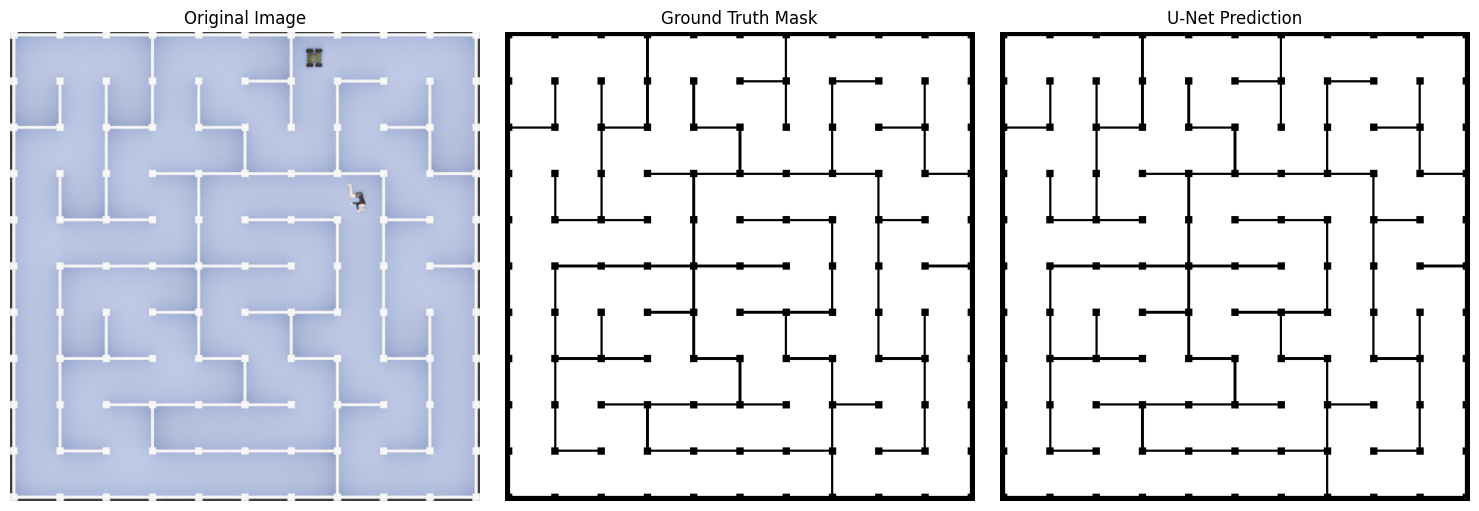

In [ ]:
# Display result

display_image = test_image_tensor.permute(1, 2, 0).numpy()
true_mask = test_mask_tensor.squeeze().numpy()

fig, arr = plt.subplots(1, 3, figsize=(15, 5))
arr[0].imshow(display_image)
arr[0].set_title("Original Image")
arr[0].axis('off')

arr[1].imshow(true_mask, cmap='gray')
arr[1].set_title("Ground Truth Mask")
arr[1].axis('off')

arr[2].imshow(binary_prediction, cmap='gray')
arr[2].set_title("U-Net Prediction")
arr[2].axis('off')

plt.tight_layout()
plt.show()